# Smoke and Mobility in California

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import json

## Make grid file
The smoke data has a 'grid_id' feature while the mobility data has an 'AREA' (GEOID) feature; we need to be able to combine these.

In [2]:
grid_10km = gpd.read_file("./10km_grid/10km_grid_wgs84/10km_grid_wgs84.shp") # has grid_id
cbg = gpd.read_file("./tl_2020_06_bg/tl_2020_06_bg.shp") # has GEOID
cbg["GEOID"] = cbg["GEOID"].astype(str)

proj_crs = "EPSG:3310"
grid_proj = grid_10km.to_crs(proj_crs)
cbg_proj = cbg.to_crs(proj_crs)

intersections = gpd.overlay(grid_proj, cbg_proj, how="intersection")
intersections["overlap_area"] = intersections.geometry.area
intersections_sorted = intersections.sort_values("overlap_area", ascending=False)
grid = intersections_sorted.drop_duplicates(subset="ID")

grid = grid.rename(columns={"ID": "grid_id_10km", "GEOID": "AREA"})
grid = grid[["grid_id_10km", "AREA", "geometry"]]
grid["AREA"] = grid["AREA"].str.lstrip("0")
grid.head()

,grid_id_10km,AREA,geometry
46323,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625..."
46322,172599,60490004001,"POLYGON ((-6416.874 426254.444, -12707.938 421..."
46161,172084,60490004001,"POLYGON ((-1218.289 419978.898, -7513.883 4148..."
46640,173628,60490003002,"POLYGON ((-23115.937 433595.383, -29391.282 42..."
46007,171568,60490004001,"POLYGON ((-2326.445 408527.131, -8619.955 4033..."


## Add smoke data to grid

In [3]:
smoke = pd.read_csv("./10km_grid/smokePM2pt5_predictions_daily_10km_20060101-20201231.csv")
smoke['date'] = pd.to_datetime(smoke['date'], format="%Y%m%d")
smoke_2020 = smoke[(smoke['date'] >= "2020-08-01") & (smoke['date'] <= "2020-09-30")]
smoke_2020.head()

,grid_id_10km,date,smokePM_pred
46997264,38438,2020-08-01,2.459065
46997265,38439,2020-08-01,2.374383
46997266,38440,2020-08-01,2.738663
46997267,38441,2020-08-01,2.587327
46997268,38442,2020-08-01,4.757607


In [4]:
# merge predictions with the grid
grid = grid.merge(smoke_2020, left_on='grid_id_10km', right_on='grid_id_10km')

# fill Na with 0
grid['smokePM_pred'] = grid['smokePM_pred'].fillna(0)

# convert to a GeoDataFrame
grid = gpd.GeoDataFrame(grid, geometry='geometry', crs=grid.crs)

grid.head()

,grid_id_10km,AREA,geometry,date,smokePM_pred
0,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-01,2.870678
1,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-03,2.281303
2,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-05,2.835910
3,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-09,0.967853
4,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-11,2.876164


In [5]:
# filter to California
states = gpd.read_file("./tl_2025_us_state/tl_2025_us_state.shp")
california = states[states["NAME"] == "California"]
california = california.to_crs(grid.crs)
grid_ca = gpd.sjoin(grid, california, how='inner', predicate='intersects')

## Add mobility data to grid

In [6]:
mobility_data = pd.read_csv("./california_202008_202009.csv")

mobility_data['DATE_RANGE_START'] = pd.to_datetime(mobility_data['DATE_RANGE_START'])

mobility_data["AREA"] = mobility_data["AREA"].astype(str).str.lstrip("0")

mobility_data['STOPS_LIST'] = mobility_data['STOPS_BY_DAY'].apply(lambda x: json.loads(x) if isinstance(x, str) else x) # convert to a python list

# we need there to be one row per day
mobility = mobility_data[['AREA','DATE_RANGE_START','STOPS_LIST']].explode('STOPS_LIST').reset_index(drop=True)
mobility['Day'] = mobility.groupby('AREA').cumcount()
mobility['date'] = mobility['DATE_RANGE_START'] + pd.to_timedelta(mobility['Day'], unit='d')
mobility['Stops'] = mobility['STOPS_LIST'].astype(int)

mobility = mobility[['AREA','date','Stops']]
mobility.head()

,AREA,date,Stops
0,60650432181,2020-08-01,1377
1,60650432181,2020-08-02,1531
2,60650432181,2020-08-03,1377
3,60650432181,2020-08-04,1469
4,60650432181,2020-08-05,1490


In [7]:
f'min: {np.min(mobility_data['DATE_RANGE_START'])}, max: {np.max(mobility_data['DATE_RANGE_START'])}'

'min: 2020-08-01 00:00:00, max: 2020-09-01 00:00:00'

So the mobility data only ranges through August.

In [8]:
grid['AREA'] = grid['AREA'].astype(str)
grid_combined = grid.merge(
    mobility,
    on=['AREA', 'date'],
    how='left'
)
#grid_combined = grid_combined.dropna(subset=['Stops'])
grid_combined = grid_combined.sort_values('date')
grid_final = grid_combined[(grid_combined['date'] <= "2020-09-01")].copy()
grid_final['Stops'] = grid_final['Stops'].fillna(0)
grid_final.head()

,grid_id_10km,AREA,geometry,date,smokePM_pred,Stops
0,172600,60490004001,"POLYGON ((-119.178 431440.327, -6416.874 42625...",2020-08-01,2.870678,1716.0
25593,168461,60350402003,"POLYGON ((-77903.56 284045.99, -84113.685 2789...",2020-08-01,1.903885,2991.0
174508,161228,61130114003,"POLYGON ((-150300.533 83050.745, -153853.65 80...",2020-08-01,1.257777,2271.0
25545,170006,60350401002,"POLYGON ((-93134.477 302659.347, -99330.735 29...",2020-08-01,1.727515,2230.0
124058,112324,60710104252,"POLYGON ((424100.166 -430099.031, 420949.533 -...",2020-08-01,6.701333,0.0


## Animate data

### Only smoke

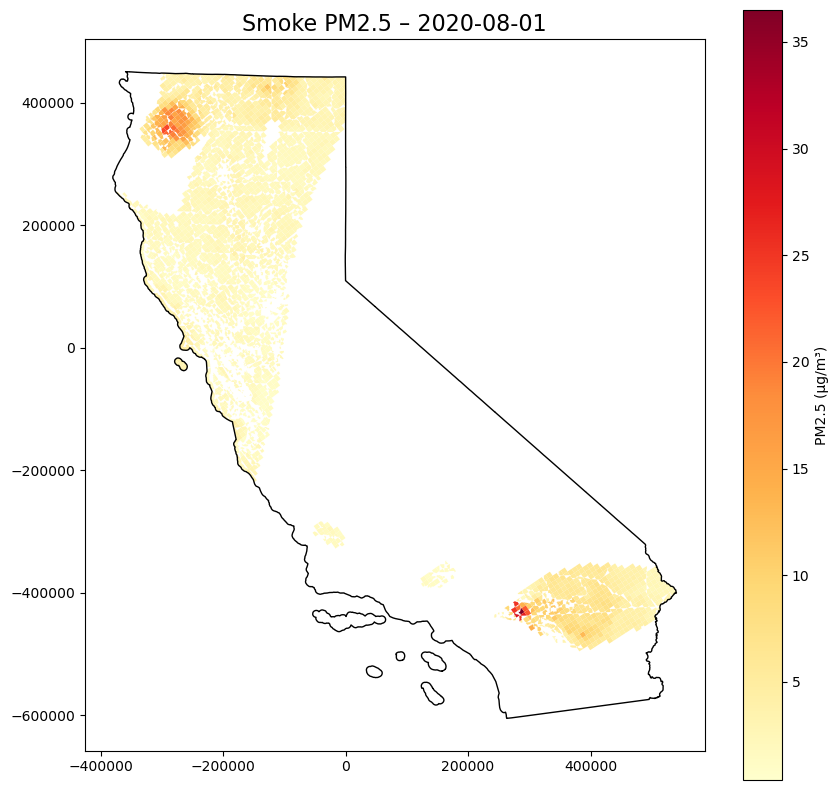

In [10]:
# set up animation
from matplotlib import animation

dates = grid_combined['date'].unique()

fig, ax = plt.subplots(figsize=(10,10))

california.plot(ax=ax, color='white')
california.boundary.plot(ax=ax, color='black', linewidth=1)


smoke_plot = grid_combined[grid_combined['date'] == dates[0]].plot(
    column='smokePM_pred', cmap='YlOrRd', legend=True, ax=ax,
    legend_kwds={'label': "PM2.5 (µg/m³)"}
)
title = ax.set_title(f"Smoke PM2.5 – {dates[0].date()}", fontsize=16)

minx, miny, maxx, maxy = california.total_bounds
vmin = grid_combined['smokePM_pred'].min()
vmax = grid_combined['smokePM_pred'].quantile(0.99)
# function to update each frame
def update(i):
    ax.clear()
    california.plot(ax=ax, color='white')
    california.boundary.plot(ax=ax, color='black', linewidth=1)
    grid_day = grid_combined[grid_combined['date'] == dates[i]]
    grid_day.plot(
        column='smokePM_pred', cmap='YlOrRd', vmin=vmin, vmax=vmax,
        legend=False, ax=ax,legend_kwds={'label': "PM2.5 (µg/m³)"}
    )
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    ax.set_title(f"Smoke PM2.5 – {dates[i].date()}", fontsize=16)
    ax.axis('off')

In [11]:
anim = FuncAnimation(fig, update, frames=len(dates), interval=300)
from IPython.display import HTML
HTML(anim.to_html5_video())

### Only mobility